---
## 0. Setup: Installs and Imports

In [1]:
# Install required packages
!pip install -q stable-baselines3[extra] imitation gymnasium numpy pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from typing import List, Sequence, Optional
import warnings

import gymnasium as gym
from gymnasium import spaces
import torch
from torch import nn
import matplotlib.pyplot as plt

from imitation.algorithms.adversarial import airl
from imitation.data import types
from imitation.rewards import reward_nets

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

print('✓ imports ok')

✓ imports ok


---
## 1. Data Access (Google Drive)

In [7]:
# Prefer local files if present; otherwise fall back to Drive
LOCAL_BASE = Path('.')
LOCAL_NPY = LOCAL_BASE / 'expert_trajectories.npy'
LOCAL_PKL = LOCAL_BASE / 'expert_trajectories.pkl'

TRAJ_PATH, FILE_FMT = None, None
if LOCAL_NPY.exists():
    TRAJ_PATH, FILE_FMT = LOCAL_NPY, 'npy'
elif LOCAL_PKL.exists():
    TRAJ_PATH, FILE_FMT = LOCAL_PKL, 'pkl'
else:
    # Colab Drive fallback
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        DRIVE_BASE = Path('/content/drive/MyDrive')
        TRAJ_NPY = DRIVE_BASE / 'expert_trajectories.npy'
        TRAJ_PKL = DRIVE_BASE / 'expert_trajectories.pkl'
        if TRAJ_NPY.exists():
            TRAJ_PATH, FILE_FMT = TRAJ_NPY, 'npy'
        elif TRAJ_PKL.exists():
            TRAJ_PATH, FILE_FMT = TRAJ_PKL, 'pkl'
    except Exception as e:
        print('Drive mount skipped/unavailable:', e)

if TRAJ_PATH is None:
    print('⚠️ No trajectory file found locally or on Drive. Place expert_trajectories.npy|pkl alongside this notebook or in Drive.')
TRAJ_PATH

WindowsPath('expert_trajectories.npy')

---
## 2. Load Trajectories (no filtering, no masking)
Inputs = full Observations; Targets = biased Actions.
Keep all trajectories (goal or not, changed or not).

In [35]:
def load_trajs(path: Path, fmt: str):
    if fmt == 'npy':
        arr = np.load(path, allow_pickle=True)
        if isinstance(arr, np.ndarray) and arr.dtype == object:
            return arr.tolist()
        return arr
    if fmt == 'pkl':
        with open(path, 'rb') as f:
            return pickle.load(f)
    raise ValueError('Unsupported format')

if TRAJ_PATH is None:
    raw_trajs = []
else:
    raw_trajs = load_trajs(TRAJ_PATH, FILE_FMT)
    print(f'Loaded {len(raw_trajs)} trajectories from {TRAJ_PATH}')
    if len(raw_trajs) > 0:
        first = raw_trajs[0]
        print('First traj type:', type(first))
        if isinstance(first, dict):
            print('Example keys:', list(first.keys()))
        elif isinstance(first, (list, tuple)):
            print('First traj len:', len(first))
            for idx, part in enumerate(first[:4]):
                try:
                    shape = np.array(part).shape
                except Exception:
                    shape = 'n/a'
                print(f'  [{idx}] type={type(part)}, shape={shape}')
        else:
            print('Unhandled traj type; please inspect raw_trajs[0] manually')

Loaded 6633 trajectories from expert_trajectories.npy
First traj type: <class 'list'>
First traj len: 17
  [0] type=<class 'int'>, shape=()
  [1] type=<class 'str'>, shape=()
  [2] type=<class 'int'>, shape=()
  [3] type=<class 'int'>, shape=()


In [36]:
# Inspect full first trajectory to map indices (arrays truncated)
if raw_trajs:
    first = raw_trajs[0]
    if isinstance(first, (list, tuple)):
        print('Full first trajectory (types / shapes / sample values):')
        for i, p in enumerate(first):
            try:
                arr = np.array(p)
            except Exception:
                arr = None
            if arr is not None and arr.ndim >= 2:
                print(f'[{i}] array shape={arr.shape}')
            elif arr is not None and arr.ndim == 1 and arr.size > 10:
                print(f'[{i}] 1d array shape={arr.shape}, head={arr[:5]}')
            else:
                val = p
                print(f'[{i}] type={type(val)}, value={val}')
    else:
        print('Not a list/tuple; skip detailed inspection')
else:
    print('No trajectories loaded to inspect')

Full first trajectory (types / shapes / sample values):
[0] type=<class 'int'>, value=0
[1] type=<class 'str'>, value=tfrecord-00000-of-01000_401
[2] type=<class 'int'>, value=63
[3] type=<class 'int'>, value=32
[4] type=<class 'int'>, value=188
[5] type=<class 'int'>, value=0
[6] type=<class 'float'>, value=18.39
[7] type=<class 'float'>, value=24.90580108926509
[8] type=<class 'float'>, value=0.098092220723629
[9] type=<class 'float'>, value=0.07671870291233063
[10] type=<class 'int'>, value=23
[11] type=<class 'bool'>, value=True
[12] type=<class 'bool'>, value=False
[13] type=<class 'int'>, value=-1
[14] type=<class 'float'>, value=0.0
[15] array shape=(23, 1848)
[16] array shape=(23, 2)


---
## 3. Convert to imitation Trajectory (no filtering)
- Ensures obs length = acts length + 1
- Keeps all trajectories (reached or not, changed or not)

In [37]:
# If your trajectories are lists/tuples, set these indices after inspecting the full sample above.
# Based on inspection: index 11=Reached Goal (bool), index 12=Action Changed (bool), 15=obs, 16=acts
REACHED_GOAL_IDX = 11
ACTION_CHANGED_IDX = 12

def _auto_extract_from_sequence(parts):
    obs_idx = None
    act_idx = None
    goal_idx = None
    for idx, p in enumerate(parts):
        arr = None
        try:
            arr = np.array(p)
        except Exception:
            arr = None
        if arr is not None and arr.dtype != object and arr.ndim >= 2:
            if arr.shape[-1] == 1848 and obs_idx is None:
                obs_idx = idx
            if arr.shape[-1] == 2 and act_idx is None:
                act_idx = idx
        if goal_idx is None and isinstance(p, (bool, np.bool_, int)):
            # treat 0/1 as goal flag fallback
            if p in [0, 1, True, False]:
                goal_idx = idx
    return obs_idx, act_idx, goal_idx

def to_imitation_trajs(
    data,
    obs_key='Observations',
    act_key='Actions',
    goal_key='Reached Goal',
    changed_key='Action Changed',
) -> List[types.Trajectory]:
    out = []
    skipped = {'length': 0, 'error': 0}
    for i, traj in enumerate(data):
        try:
            # Dict case (expected)
            if isinstance(traj, dict):
                obs = np.array(traj[obs_key], dtype=np.float32)
                acts = np.array(traj[act_key], dtype=np.float32)
                reached_goal = bool(traj.get(goal_key, False))
            # Sequence case with unknown layout
            elif isinstance(traj, (list, tuple)):
                parts = list(traj)
                obs_idx, act_idx, goal_idx_auto = _auto_extract_from_sequence(parts)
                goal_idx = REACHED_GOAL_IDX if REACHED_GOAL_IDX is not None else goal_idx_auto
                if obs_idx is None or act_idx is None:
                    skipped['length'] += 1
                    continue
                obs = np.array(parts[obs_idx], dtype=np.float32)
                acts = np.array(parts[act_idx], dtype=np.float32)
                reached_goal = bool(parts[goal_idx]) if goal_idx is not None else False
            else:
                obs = np.array(getattr(traj, obs_key), dtype=np.float32)
                acts = np.array(getattr(traj, act_key), dtype=np.float32)
                reached_goal = bool(getattr(traj, goal_key, False))
            if len(obs) == 0 or len(acts) == 0:
                skipped['length'] += 1
                continue
            if len(obs) == len(acts):
                obs = np.vstack([obs, obs[-1:]])
            if len(obs) != len(acts) + 1:
                skipped['length'] += 1
                continue
            out.append(types.Trajectory(obs=obs, acts=acts, infos=None, terminal=reached_goal))
        except Exception as e:
            skipped['error'] += 1
            if skipped['error'] <= 3:
                print(f'Warning on traj {i}: {e}')
    print(f'Converted {len(out)} trajectories; skipped {skipped}')
    return out

expert_demos = to_imitation_trajs(raw_trajs) if len(raw_trajs) else []
ACTION_ABS_MAX = 1.0
if raw_trajs:
    # Compute max abs action from raw data to size the action space
    acts_list = []
    for traj in raw_trajs:
        if isinstance(traj, dict) and 'Actions' in traj:
            acts_list.append(np.array(traj['Actions']))
        elif isinstance(traj, (list, tuple)) and len(traj) > 16:
            acts_list.append(np.array(traj[16]))
    if acts_list:
        ACTION_ABS_MAX = float(np.max([np.max(np.abs(a)) for a in acts_list]))
        ACTION_ABS_MAX = max(1.0, ACTION_ABS_MAX)
        print('Detected max abs action:', ACTION_ABS_MAX)
if expert_demos:
    s = expert_demos[0]
    print('Sample shapes:', s.obs.shape, s.acts.shape, 'terminal:', s.terminal)

Converted 6633 trajectories; skipped {'length': 0, 'error': 0}
Detected max abs action: 10.0
Sample shapes: (24, 1848) (23, 2) terminal: True


---
## 4. Dummy Env (spaces only) for AIRL
We don't need the simulator; env provides obs/act spaces and a replay-based step.

In [38]:
class DummyPufferDriveEnv(gym.Env):
    metadata = {'render_modes': []}
    def __init__(self, obs_dim=1848, act_dim=2, act_bound=1.0, max_steps=91, trajectories: Optional[Sequence[types.Trajectory]] = None):
        super().__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.act_bound = act_bound
        self.max_steps = max_steps
        self.trajectories = trajectories or []
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-act_bound, high=act_bound, shape=(act_dim,), dtype=np.float32)
        self._rng = np.random.default_rng()
        self._cur = None
        self._t = 0
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        if self.trajectories:
            self._cur = self._rng.integers(0, len(self.trajectories))
            self._traj = self.trajectories[self._cur]
            self._t = 0
            return self._traj.obs[0], {}
        return self._rng.standard_normal(self.obs_dim).astype(np.float32), {}
    def step(self, action):
        if self.trajectories:
            self._t += 1
            done = self._t >= len(self._traj.acts)
            truncated = self._t >= self.max_steps
            obs = self._traj.obs[min(self._t, len(self._traj.obs)-1)]
            reward = 1.0 if (done and self._traj.terminal) else -0.01
            return obs, reward, done, truncated, {}
        obs = self._rng.standard_normal(self.obs_dim).astype(np.float32)
        return obs, 0.0, False, False, {}
    def close(self):
        pass

def make_vec_env(n_envs=4, trajectories=None, obs_dim=1848, act_dim=2, act_bound=1.0):
    def _f():
        return DummyPufferDriveEnv(obs_dim=obs_dim, act_dim=act_dim, act_bound=act_bound, trajectories=trajectories)
    return VecMonitor(DummyVecEnv([_f for _ in range(n_envs)]))

print('✓ Dummy env ready')

✓ Dummy env ready


---
## 5. Build AIRL (PPO generator)

In [39]:
def build_airl(expert_demos, vec_env, lr=3e-4, demo_batch_size=512, n_disc_updates=4):
    learner = PPO("MlpPolicy", vec_env, learning_rate=lr, batch_size=2048, n_steps=2048, gamma=0.99, gae_lambda=0.95, verbose=1)
    reward_net = reward_nets.BasicShapedRewardNet(vec_env.observation_space, vec_env.action_space)
    trainer = airl.AIRL(
        demonstrations=expert_demos,
        demo_batch_size=demo_batch_size,
        gen_replay_buffer_capacity=2048,
        n_disc_updates_per_round=n_disc_updates,
        venv=vec_env,
        gen_algo=learner,
        reward_net=reward_net,
        allow_variable_horizon=True,  # our demos have variable lengths
    )
    return trainer, learner

if expert_demos:
    obs_dim = expert_demos[0].obs.shape[1]
    act_dim = expert_demos[0].acts.shape[1]
    act_bound = ACTION_ABS_MAX if 'ACTION_ABS_MAX' in globals() else 1.0
    vec_env = make_vec_env(4, expert_demos, obs_dim=obs_dim, act_dim=act_dim, act_bound=act_bound)
    trainer, learner = build_airl(expert_demos, vec_env)
    print('✓ AIRL trainer ready with act_bound', act_bound)
else:
    print('⚠️ No expert demos loaded')

Using cpu device
Running with `allow_variable_horizon` set to True. Some algorithms are biased towards shorter or longer episodes, which may significantly confound results. Additionally, even unbiased algorithms can exploit the information leak from the termination condition, producing spuriously high performance. See https://imitation.readthedocs.io/en/latest/getting-started/variable-horizon.html for more information.
Running with `allow_variable_horizon` set to True. Some algorithms are biased towards shorter or longer episodes, which may significantly confound results. Additionally, even unbiased algorithms can exploit the information leak from the termination condition, producing spuriously high performance. See https://imitation.readthedocs.io/en/latest/getting-started/variable-horizon.html for more information.
✓ AIRL trainer ready with act_bound 10.0
✓ AIRL trainer ready with act_bound 10.0


---
## 6. Train AIRL

In [40]:
TOTAL_TIMESTEPS = 100_000  # adjust for budget
if 'trainer' in globals():
    print(f'Training for {TOTAL_TIMESTEPS:,} timesteps')
    trainer.train(total_timesteps=TOTAL_TIMESTEPS)
    print('✓ training done')
else:
    print('⚠️ Trainer not initialized')

Training for 100,000 timesteps


round:   0%|          | 0/12 [00:00<?, ?it/s]

------------------------------------------
| raw/                        |          |
|    gen/rollout/ep_len_mean  | 30.2     |
|    gen/rollout/ep_rew_mean  | 0.688    |
|    gen/time/fps             | 1956     |
|    gen/time/iterations      | 1        |
|    gen/time/time_elapsed    | 4        |
|    gen/time/total_timesteps | 8192     |
------------------------------------------
--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 0.5      |
|    disc/disc_acc_expert             | 1        |
|    disc/disc_acc_gen                | 0        |
|    disc/disc_entropy                | 0.118    |
|    disc/disc_loss                   | 1.5      |
|    disc/disc_proportion_expert_pred | 1        |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 1        |
|    disc/n_expert                    | 512      |
|    disc/n_generated                 | 512      |
-

round:   8%|▊         | 1/12 [00:05<01:01,  5.63s/it]

-----------------------------------------------------
| raw/                               |              |
|    gen/rollout/ep_len_mean         | 31.4         |
|    gen/rollout/ep_rew_mean         | 0.686        |
|    gen/rollout/ep_rew_wrapped_mean | 1.38         |
|    gen/time/fps                    | 2699         |
|    gen/time/iterations             | 1            |
|    gen/time/time_elapsed           | 3            |
|    gen/time/total_timesteps        | 16384        |
|    gen/train/approx_kl             | 0.0029022794 |
|    gen/train/clip_fraction         | 0.0062       |
|    gen/train/clip_range            | 0.2          |
|    gen/train/entropy_loss          | -2.83        |
|    gen/train/explained_variance    | -0.413       |
|    gen/train/learning_rate         | 0.0003       |
|    gen/train/loss                  | 0.0679       |
|    gen/train/n_updates             | 10           |
|    gen/train/policy_gradient_loss  | -0.00575     |
|    gen/train/std          

...

------------------------------------------------------
| raw/                               |               |
|    gen/rollout/ep_len_mean         | 35            |
|    gen/rollout/ep_rew_mean         | 0.59          |
|    gen/rollout/ep_rew_wrapped_mean | -231          |
|    gen/time/fps                    | 2580          |
|    gen/time/iterations             | 1             |
|    gen/time/time_elapsed           | 3             |
|    gen/time/total_timesteps        | 90112         |
|    gen/train/approx_kl             | 2.7567949e-06 |
|    gen/train/clip_fraction         | 0             |
|    gen/train/clip_range            | 0.2           |
|    gen/train/entropy_loss          | -2.83         |
|    gen/train/explained_variance    | 0.00381       |
|    gen/train/learning_rate         | 0.0003        |
|    gen/train/loss                  | 3.26e+03      |
|    gen/train/n_updates             | 100           |
|    gen/train/policy_gradient_loss  | -8.78e-05     |
|    gen/t

round:  92%|█████████▏| 11/12 [00:56<00:05,  5.95s/it]

-----------------------------------------------------
| raw/                               |              |
|    gen/rollout/ep_len_mean         | 34.3         |
|    gen/rollout/ep_rew_mean         | 0.616        |
|    gen/rollout/ep_rew_wrapped_mean | -265         |
|    gen/time/fps                    | 1312         |
|    gen/time/iterations             | 1            |
|    gen/time/time_elapsed           | 6            |
|    gen/time/total_timesteps        | 98304        |
|    gen/train/approx_kl             | 2.884335e-07 |
|    gen/train/clip_fraction         | 0            |
|    gen/train/clip_range            | 0.2          |
|    gen/train/entropy_loss          | -2.83        |
|    gen/train/explained_variance    | 0.00549      |
|    gen/train/learning_rate         | 0.0003       |
|    gen/train/loss                  | 3.76e+03     |
|    gen/train/n_updates             | 110          |
|    gen/train/policy_gradient_loss  | -6.29e-05    |
|    gen/train/std          

round: 100%|██████████| 12/12 [01:05<00:00,  5.44s/it]

✓ training done


---
## 7. Negative Log-Likelihood (NLL) of expert actions under AIRL policy
High NLL ⇒ policy does *not* explain the biased expert (paper's finding).

In [41]:
def compute_action_nll(policy: PPO, trajectories: Sequence[types.Trajectory], max_trajs=200):
    # Use the underlying policy network; PPO object itself has no eval()
    policy.policy.eval()
    logps = []
    with torch.no_grad():
        for traj in trajectories[:max_trajs]:
            obs_t = torch.tensor(traj.obs[:-1], dtype=torch.float32)  # T x obs_dim
            act_t = torch.tensor(traj.acts, dtype=torch.float32)      # T x act_dim
            dist = policy.policy.get_distribution(obs_t)
            lp = dist.log_prob(act_t)  # (T, act_dim) or (T,)
            if lp.dim() > 1:
                lp = lp.sum(-1)  # sum over action dims
            logps.append(lp.cpu().numpy())
    if not logps:
        return None
    logp_all = np.concatenate(logps)
    nll = -np.mean(logp_all)
    return {'nll': float(nll), 'mean_logp': float(np.mean(logp_all)), 'std_logp': float(np.std(logp_all)), 'samples': len(logp_all)}

nll_result = compute_action_nll(learner, expert_demos) if expert_demos else None
nll_result

{'nll': 38.476051330566406,
 'mean_logp': -38.476051330566406,
 'std_logp': 10.494399070739746,
 'samples': 6007}

---
## 8. Qualitative plots on "Action Changed" cases
Visual check: does AIRL also ignore the closest car, or just act noisily?

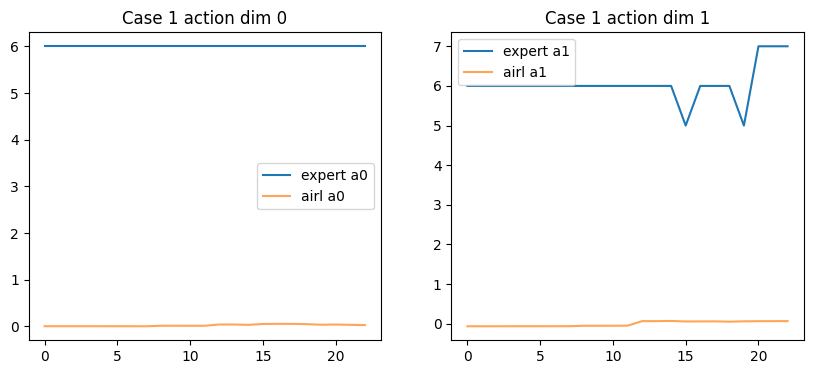

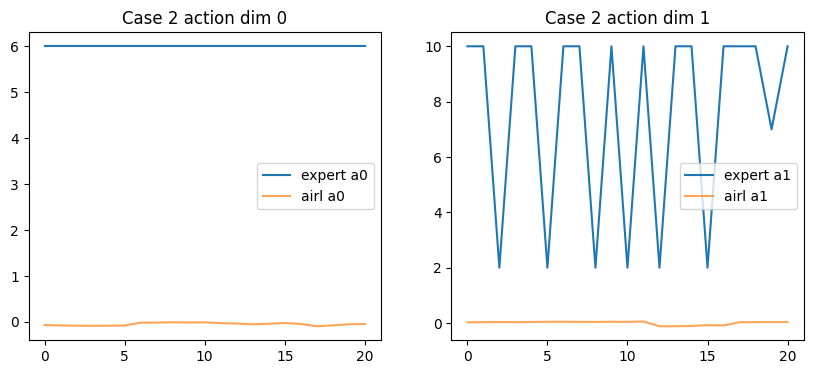

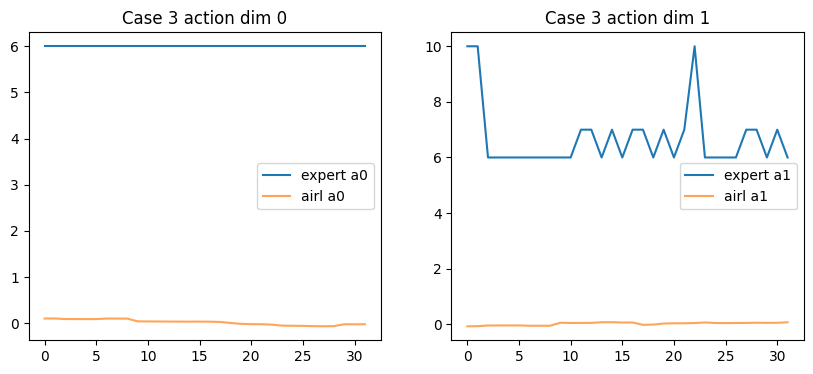

In [42]:
def plot_action_changed_cases(policy: PPO, data, max_cases=3, obs_key='Observations', act_key='Actions', changed_key='Action Changed', changed_idx_key='Action Changed at Index'):
    cases = []
    for traj in data:
        flag = False
        if isinstance(traj, dict):
            flag = bool(traj.get(changed_key, False))
        elif isinstance(traj, (list, tuple)) and ACTION_CHANGED_IDX is not None and ACTION_CHANGED_IDX < len(traj):
            flag = bool(traj[ACTION_CHANGED_IDX])
        else:
            flag = bool(getattr(traj, changed_key, False))
        if flag:
            cases.append(traj)
        if len(cases) >= max_cases:
            break
    if not cases:
        print('No action-changed cases found')
        return
    for i, traj in enumerate(cases, 1):
        if isinstance(traj, dict):
            obs = np.array(traj[obs_key])
            acts = np.array(traj[act_key])
        elif isinstance(traj, (list, tuple)):
            parts = list(traj)
            obs_idx, act_idx, _ = _auto_extract_from_sequence(parts)
            if obs_idx is None or act_idx is None:
                print(f'Skip case {i}: could not locate obs/acts indices')
                continue
            obs = np.array(parts[obs_idx])
            acts = np.array(parts[act_idx])
        else:
            obs = np.array(getattr(traj, obs_key))
            acts = np.array(getattr(traj, act_key))
        with torch.no_grad():
            dist = policy.policy.get_distribution(torch.tensor(obs[:-1], dtype=torch.float32))
            # DiagGaussianDistribution has underlying Normal at dist.distribution
            policy_actions = dist.distribution.mean.cpu().numpy() if hasattr(dist, 'distribution') else dist.mean.cpu().numpy()
        # align lengths (policy_actions matches obs[:-1] length). acts length should match policy_actions
        min_len = min(len(acts), len(policy_actions))
        acts_to_plot = acts[:min_len]
        policy_to_plot = policy_actions[:min_len]
        t = np.arange(min_len)
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.plot(t, acts_to_plot[:,0], label='expert a0')
        plt.plot(t, policy_to_plot[:,0], label='airl a0', alpha=0.7)
        plt.title(f'Case {i} action dim 0')
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(t, acts_to_plot[:,1], label='expert a1')
        plt.plot(t, policy_to_plot[:,1], label='airl a1', alpha=0.7)
        plt.title(f'Case {i} action dim 1')
        plt.legend()
        plt.show()

plot_action_changed_cases(learner, raw_trajs) if raw_trajs else None

---
## 9. Task Performance Proxy (Goal %)
Collision % needs the simulator; here we compare Goal Reached %.

In [43]:
def goal_rate(trajs):
    goals = []
    for traj in trajs:
        if isinstance(traj, dict):
            flag = traj.get('Reached Goal', False)
        elif isinstance(traj, (list, tuple)) and REACHED_GOAL_IDX is not None and REACHED_GOAL_IDX < len(traj):
            flag = traj[REACHED_GOAL_IDX]
        else:
            flag = getattr(traj, 'Reached Goal', False)
        goals.append(bool(flag))
    return np.mean(goals) if goals else np.nan

expert_goal_rate = goal_rate(raw_trajs) if raw_trajs else np.nan
print('Expert goal rate:', expert_goal_rate)

Expert goal rate: 0.9698477310417609


---
## 10. Save outputs
(Optional) Save AIRL policy, reward net, and metrics to Drive.

In [ ]:
SAVE_DIR = DRIVE_BASE / 'airl_bias_outputs'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
if 'learner' in globals():
    policy_path = SAVE_DIR / 'airl_policy.zip'
    learner.save(policy_path)
    torch.save(trainer.reward_net.state_dict(), SAVE_DIR / 'airl_reward_net.pt')
    if nll_result:
        with open(SAVE_DIR / 'nll_result.pkl', 'wb') as f:
            pickle.dump(nll_result, f)
    print('✓ saved policy and reward net to', SAVE_DIR)
else:
    print('⚠️ nothing to save')

---
## 11. Reporting Checklist
- NLL of expert actions under AIRL policy (higher → fails to capture bias)
- Action plots on "Action Changed" cases (does AIRL ignore closest car or just act noisy?)
- Goal % vs expert (collision % requires simulator)
- If you can run the simulator: check whether AIRL actually ignores the closest car in rollout